## **Project Name - Email Spam Detection with Machine Learning**


#### **Problem Statement**

In the digital communication era, email remains a dominant medium for personal and professional interaction. However, the widespread use of emails has led to a surge in spam messages—unwanted, unsolicited, and often malicious emails that clutter inboxes and pose security threats. These spam emails can lead to phishing attacks, financial fraud, and data breaches. Therefore, building an intelligent and efficient system that can automatically detect and filter spam emails is crucial. This project aims to develop a machine learning model that can accurately classify emails as spam or ham (non-spam) based on their content.


**Objectives**

**1. Data Acquisition & Exploration**

Load and examine the structure of the email dataset.
Understand the distribution and characteristics of spam vs. ham messages.


**2. Data Cleaning & Preprocessing**

Remove irrelevant columns and handle missing or duplicate entries.
Normalize and prepare text data for modeling.

**3. Feature Engineering**

Convert raw text into numerical features using techniques like CountVectorizer.

**4. Model Building**

Implement a classification model (e.g., Naive Bayes) suitable for text classification tasks.

**5. Model Evaluation**

Evaluate model performance using metrics such as accuracy, precision, recall, F1-score, and ROC-AUC.

**6. Model Optimization**

Tune parameters and optimize the pipeline to improve predictive performance.

**7. Deployment Readiness**

Prepare the model for real-world application, such as integrating into an email client.

**8. Spam Prediction Interface**

Create a function/interface to predict whether a given email text is spam or ham.


####  *1.Import Libraries*

In [1909]:
# import main libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library used for data preprocessing
from sklearn.feature_extraction.text import CountVectorizer


# Model selection & evaluation
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)

# Warning management
import warnings
warnings.filterwarnings('ignore')


#### *2. Data loading ,analysing and wrangling*

In [1910]:
# Load the dataset
df = pd.read_csv("spam.csv", encoding='ISO-8859-1')  # encoding is often needed for spam datasets

# Display the first 5 rows
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [1911]:
# Dataset Info
# Checking information about the dataset using info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [1912]:
# Dataset Duplicate Value Count
dup = df.duplicated().sum()
print(f'number of duplicated rows are {dup}')

# Missing Values/Null Values Count
df.isnull().sum()

number of duplicated rows are 403


v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

*  *No Null values exist in v1 & v2 column, but lots of null values present in unnamed 2,3,4 columns (will drop those 3 columns later).*

In [1913]:
# Rename columns for clarity
df.rename(columns={"v1": "Category", "v2": "Message"}, inplace=True)

# Drop all columns that start with "Unnamed"
df.drop(columns=[col for col in df.columns if 'Unnamed' in col], inplace=True)

# Add a binary 'Spam' column: 1 for 'spam', 0 for 'ham'
df['Spam'] = df['Category'].map({'spam': 1, 'ham': 0})

# Preview the cleaned dataset
df.head()

,Category,Message,Spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


#### *3. Data Visualization*

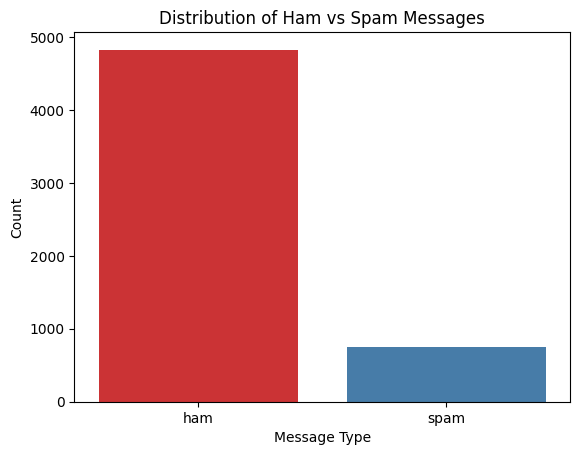

In [1914]:
#Bar Plot Visualization Code For Distribution of Spam vs Ham Messages
sns.countplot(data=df, x='Category', palette='Set1')
plt.title("Distribution of Ham vs Spam Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()

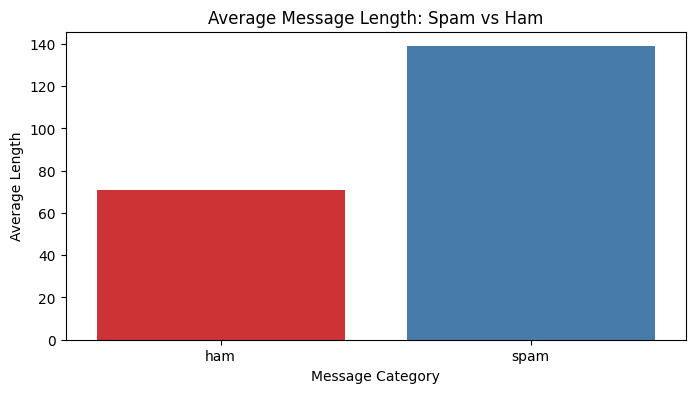

In [1915]:
# Step 1: Create a new column for message length
df['Message_Length'] = df['Message'].apply(len)

# Step 2: Group by Category and calculate average length
avg_lengths = df.groupby('Category')['Message_Length'].mean().reset_index()

# Step 3: Plot the bar chart
plt.figure(figsize=(8,4))
sns.barplot(data=avg_lengths, x='Category', y='Message_Length', palette='Set1')
plt.title("Average Message Length: Spam vs Ham")
plt.xlabel("Message Category")
plt.ylabel("Average Length")
plt.show()

#### *4. Data Splitting*

In [1916]:
X = df['Message'] 
y = df['Spam']             # Target (0 for ham, 1 for spam)

# 80% train, 20% test split
# Splitting the data to train and test
X_train,X_test,y_train,y_test=train_test_split(df.Message,df.Spam,test_size=0.20,random_state=42)




#### *5. Model Implementation*

In [1917]:


def evaluate_model(model, X_train, X_test, y_train, y_test):
    # Fit the model
    model.fit(X_train, y_train)

    # Predict classes and probabilities
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    prob_train = model.predict_proba(X_train)[:, 1]
    prob_test = model.predict_proba(X_test)[:, 1]

    # Confusion matrices
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    sns.heatmap(confusion_matrix(y_train, y_pred_train), annot=True, cmap="Blues", fmt="d", ax=ax[0])
    ax[0].set_title("Train Confusion Matrix")
    ax[0].set_xlabel("Predicted")
    ax[0].set_ylabel("Actual")

    sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, cmap="Oranges", fmt="d", ax=ax[1])
    ax[1].set_title("Test Confusion Matrix")
    ax[1].set_xlabel("Predicted")
    ax[1].set_ylabel("Actual")

    plt.tight_layout()
    plt.show()

    # Classification reports
    print("\nTrain Classification Report:")
    cr_train = classification_report(y_train, y_pred_train, output_dict=True)
    print(classification_report(y_train, y_pred_train))

    print("Test Classification Report:")
    cr_test = classification_report(y_test, y_pred_test, output_dict=True)
    print(classification_report(y_test, y_pred_test))

    # Extract weighted metrics
    precision_train = cr_train['weighted avg']['precision']
    recall_train = cr_train['weighted avg']['recall']
    f1_train = cr_train['weighted avg']['f1-score']
    acc_train = accuracy_score(y_train, y_pred_train)

    precision_test = cr_test['weighted avg']['precision']
    recall_test = cr_test['weighted avg']['recall']
    f1_test = cr_test['weighted avg']['f1-score']
    acc_test = accuracy_score(y_test, y_pred_test)

    # Threshold tuning curve (F1 Score vs Threshold)
    thresholds = np.arange(0.1, 1.0, 0.01)
    f1_scores_train = []
    f1_scores_test = []

    for t in thresholds:
        y_pred_train_thresh = (prob_train >= t).astype(int)
        y_pred_test_thresh = (prob_test >= t).astype(int)
        f1_scores_train.append(f1_score(y_train, y_pred_train_thresh))
        f1_scores_test.append(f1_score(y_test, y_pred_test_thresh))

    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, f1_scores_train, label='Train F1 Score', linestyle='--', color='blue')
    plt.plot(thresholds, f1_scores_test, label='Test F1 Score', color='green')
    plt.xlabel('Decision Threshold')
    plt.ylabel('F1 Score')
    plt.title('F1 Score vs. Decision Threshold (Train vs. Test)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return {
        'Precision': {'Train': precision_train, 'Test': precision_test},
        'Recall': {'Train': recall_train, 'Test': recall_test},
        'Accuracy': {'Train': acc_train, 'Test': acc_test},
        'F1 Score': {'Train': f1_train, 'Test': f1_test}
    }


In [1918]:
# ML Model - 1 Implementation
# Create a machine learning pipeline using scikit-learn, combining text vectorization (CountVectorizer)
# and a Multinomial Naive Bayes classifier for email spam detection.
clf = Pipeline([
    ('vectorizer', CountVectorizer()),  # Step 1: Text data transformation
    ('nb', MultinomialNB())  # Step 2: Classification using Naive Bayes
])

# Model is trained (fit) and predicted in the evaluate model

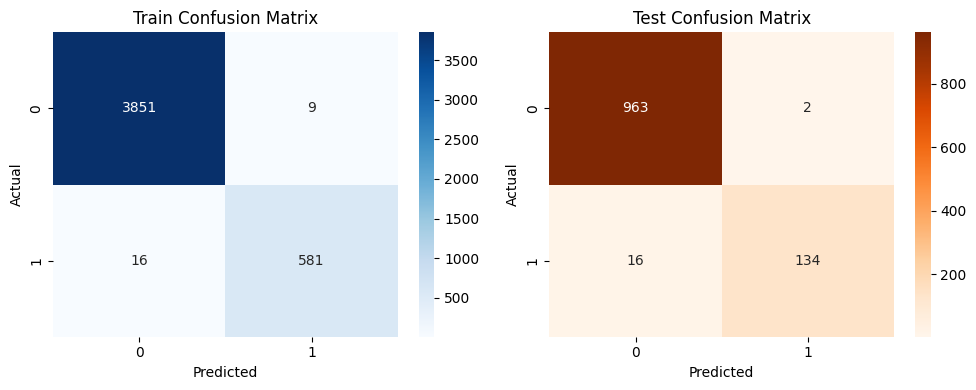


Train Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3860
           1       0.98      0.97      0.98       597

    accuracy                           0.99      4457
   macro avg       0.99      0.99      0.99      4457
weighted avg       0.99      0.99      0.99      4457

Test Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.89      0.94       150

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



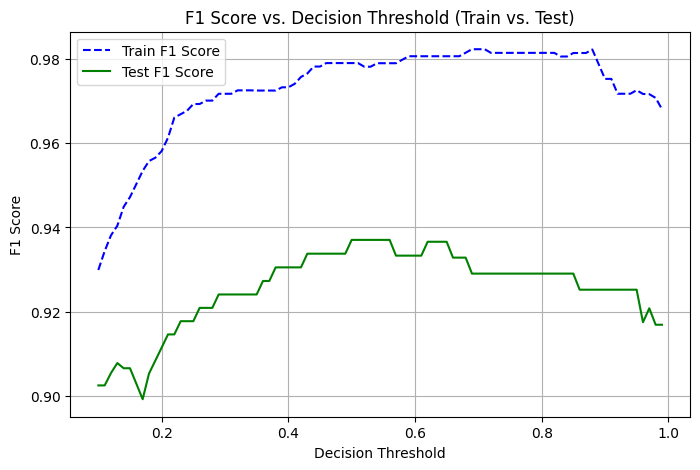

In [1919]:
# Visualizing evaluation Metric Score chart
MultinomialNB_score = evaluate_model (clf, X_train, X_test, y_train, y_test)

#### *6. Email Spam Detection System*

In [1920]:
# Defining a function for the Email Spam Detection System
def detect_spam(email_text):
    # Load the trained classifier (clf) here
    # Replace the comment with your code to load the classifier model
     prediction = clf.predict([email_text])[0]
     return "Ham Email " if prediction == 0 else "Spam Email "



In [1921]:
# Example of how to use the function
email = "Win a brand new iPhone today!"
result = detect_spam(email)
print(result)

Spam Email 
